In [1]:
import scanpy as sc
import anndata as ad
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42 # ADOBE AI 字帖

from matplotlib.font_manager import fontManager, FontProperties

fontManager.addfont('/data/work/Arial.ttf')

font = FontProperties(fname='/data/work/Arial.ttf')
font_name = font.get_name()
plt.rcParams['font.family'] = font_name

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

colors = [
    "navy",                 
    "white",                
    (205 / 255, 41 / 255, 41 / 255)  
]

cmap = mcolors.LinearSegmentedColormap.from_list("custom_colormap", colors, N=100)

In [3]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/0106/Hippocampus_latent_embeddings_all_single_pretrain/dmt_leiden_20250108_1.h5ad')
adata

AnnData object with n_obs × n_vars = 1112773 × 33326
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge', 'dmt_leiden_anno'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [4]:
names = [
    'B03607C4E6_WT2024071214941.h5ad',
    
    '12_B03605F3G5_WT202403310048.h5ad',
    '13_B03612A1C3_WT202403310056.h5ad',
    '14_A03591A1C3_WT202403310045.h5ad',
    '16_A03592A4C6_WT202403310044.h5ad',
    '18_B03602C4D6_WT202405020031.h5ad',
    '20_B03606F3G5_WT202405020032.h5ad',
    '22_B03606C4E6_WT202403310050.h5ad',
    '23_B03609A4D6_WT202404150263.h5ad',
    '27_B03610C1E3_WT202403310051.h5ad',
    '31_B03619A1D3_WT202403310052.h5ad',
    '35_B03619E4G6_WT202403310053.h5ad',
    '39_A03589A1D4_WT202403310046.h5ad',
    '43_A03590E1G4_WT202403310064.h5ad',
    '47_A03593C1F3_WT202403310068.h5ad',
]

In [5]:
adatas = []
for i in set(adata.obs['slice_code']):
    temp = adata[adata.obs['slice_code'] == i].copy()
    sc.pp.normalize_total(temp)
    sc.pp.log1p(temp)
    sc.pp.scale(temp, zero_center=False, max_value=10)
    adatas.append(temp)
adata = ad.concat(adatas)

In [6]:
adata.obs_names_make_unique()

In [7]:
dic_dmt_leiden = {
   
    
    '2': 'ctx_sc_01',
    '13': 'ctx_sc_02',
    '19': 'ctx_sc_03',
    '20': 'ctx_sc_04',
    
    '4': 'ctx_sc_05',
    '21': 'ctx_sc_05',
    
    '8': 'ctx_sc_06',
    '10': 'ctx_sc_07',
    '22': 'ctx_sc_08',
    
    '9': 'ctx_sc_09',
    '11': 'ctx_sc_09',
    '16': 'ctx_sc_10',
    '18': 'ctx_sc_10',
    '26': 'ctx_sc_10',
    '31': 'ctx_sc_10',
    
    '12': 'ctx_sc_11',
    '15': 'ctx_sc_12',
    '25': 'ctx_sc_12',
    '29': 'ctx_sc_12',
    '17': 'ctx_sc_13',
    
    '24': 'z_delete',
    
    
    '5': 'ctx_sc_14',
    '23': 'ctx_sc_15',
    '27': 'ctx_sc_16',
    
    '30': 'ctx_sc_17',
    
     '0': 'hip_sc_18',
    '7': 'hip_sc_19',
    
    '1': 'hip_sc_20',
    '3': 'hip_sc_21',
    '6': 'hip_sc_21',
    '14': 'hip_sc_22',
    '28': 'hip_sc_23',
}
adata.obs['dmt_leiden_anno'] = [dic_dmt_leiden[i] for i in adata.obs['dmt_leiden']]


In [8]:
adata = adata[adata.obs['dmt_leiden_anno'] != 'z_delete']

In [9]:
colormap = {
 
  'ctx_sc_01' : '#374898',
  'ctx_sc_02' : '#6d85c7',
  'ctx_sc_03' : '#35c498',
  'ctx_sc_04' : '#9e2dc6',
  'ctx_sc_05' : '#2d7476',
  'ctx_sc_06' : '#cb0d6c',
  'ctx_sc_07' : '#20ea38',
  'ctx_sc_08' : '#0fabb6',
  'ctx_sc_09' : '#a59099',
  'ctx_sc_10' : '#2bea3a',
  'ctx_sc_11' : '#17b064',
  'ctx_sc_12' : '#52b8d5',
  'ctx_sc_13' : '#da2ef2',
  'ctx_sc_14' : '#6240f7',
  'ctx_sc_15' : '#c47233',
  'ctx_sc_16':'#a83b23',
  'ctx_sc_17':'#9994da',
  'hip_sc_18' : '#9b38e9',
  'hip_sc_19' : '#a89630',
  'hip_sc_20': '#5b798b',
  'hip_sc_21' : '#cb2505',
  'hip_sc_22' : '#62e7dd',
  'hip_sc_23' : '#245200',
}

In [16]:
colormap.keys()

dict_keys(['ctx_sc_01', 'ctx_sc_02', 'ctx_sc_03', 'ctx_sc_04', 'ctx_sc_05', 'ctx_sc_06', 'ctx_sc_07', 'ctx_sc_08', 'ctx_sc_09', 'ctx_sc_10', 'ctx_sc_11', 'ctx_sc_12', 'ctx_sc_13', 'ctx_sc_14', 'ctx_sc_15', 'ctx_sc_16', 'ctx_sc_17', 'hip_sc_18', 'hip_sc_19', 'hip_sc_20', 'hip_sc_21', 'hip_sc_22', 'hip_sc_23'])

In [10]:
plot = sc.pl.embedding(adata, basis = 'X_dmt',color = 'dmt_leiden_anno', palette = colormap, show = False, title = 'Hip&Cortex SpatialSingelCell Annotation'); 
plot.set_aspect('equal')
plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_single/dmt_plot.png', bbox_inches = 'tight', dpi = 600)
plt.close()

In [11]:
var = [
    
    
    'TOP2A',  'HMGB2', 'UBE2C', 'CENPF',  # hip_2_1
    'ROBO2', 'DPY19L1', 'NRG1', 'CCSER1', 'SOX11', # hip_2_2
    'DDAH2', 'TUBB2B',  'HNRNPA1', 'ACTG1', 'RPL10',  #  hip_2_3
    'ACTB', 'PRDX1', 'TMSB4X', 'GAPDH', 'HES6',  # hip_2_4
    
    'AC104389.5', 'HBG2', # 'AC104389.4', 'ALAS2',  # HB+ CELL # hip_3_1
    
    'HSPA1A', 'HSP90AA1', 'HSPA1B', 'DNAJB1', 'HSPA8', # hip_5_1
    'NFIB', 'NEUROD2', 'NEUROD6', 'SOX4', 'NCAM1', # hip_5_2
    'CRYM', 'FEZF2', 'WASF1',  # hip_5_3
    
    'EEF1A1', 'EEF1G', 'CDR1', 'ATP5F1E', 'COX7C', 'TPT1', # hip_6_1 hip_6_2
    
    'CLDN5', 'FN1', 'ITM2A', 'IGFBP7', # hip_7_1
    
    'LMO3', 'CALM1', 'GPM6A', 'RTN1', 'NSG2', 'RBPJ', 'NPR3', # hip_8_1
    'SOX5', 'PTPRD', 'RBFOX1', 'SSBP2', 'LRRTM4', # hip_8_2
    
    'VIM',  'PTN', 'HES1', 'FABP5', 'H2AFZ',  # hip_10_1
    'TUBA1B', 'DBI', 'MYL6','FABP7', # hip_10_2
    'FGFR3', 'SOX2', 'QKI', # hip_10_3
   
    'MALAT1', 'NKAIN3',  # hip_10_5
    
    'STMN2', 'TUBA1A', 'MAP1B', 'GAP43', 'AC092143.1', 'UCHL1',  # hip_0_1
    'NTS', 'NREP', 'ISLR2',  # hip_0_2
    
    'NNAT', 'BHLHE22',  # 'NPTXR', 'SEMA3C', 'SSTR2', 'PLEKHN1', 'RASD1', 'PRKX', # hip_1_1
    'TTR', # 'WFIKKN2', 'FOLR1', 'PRAP1', 'AQP1', # hip_1_2
    'NFIA', 'TCF4', 'DCX', 'RTN4', 'ZBTB20',    # 'PLXNB3', 'AGT', 'HRK', 'AC239803.3', 'KLLN', 'RSPO3', # hip_1_3
     'CRYAB', 'SLC1A3', 'ZFP36L1',  # hip_10_4
    
    # 'SLC17A6',
    # 'GAD1', 'GAD2'
]

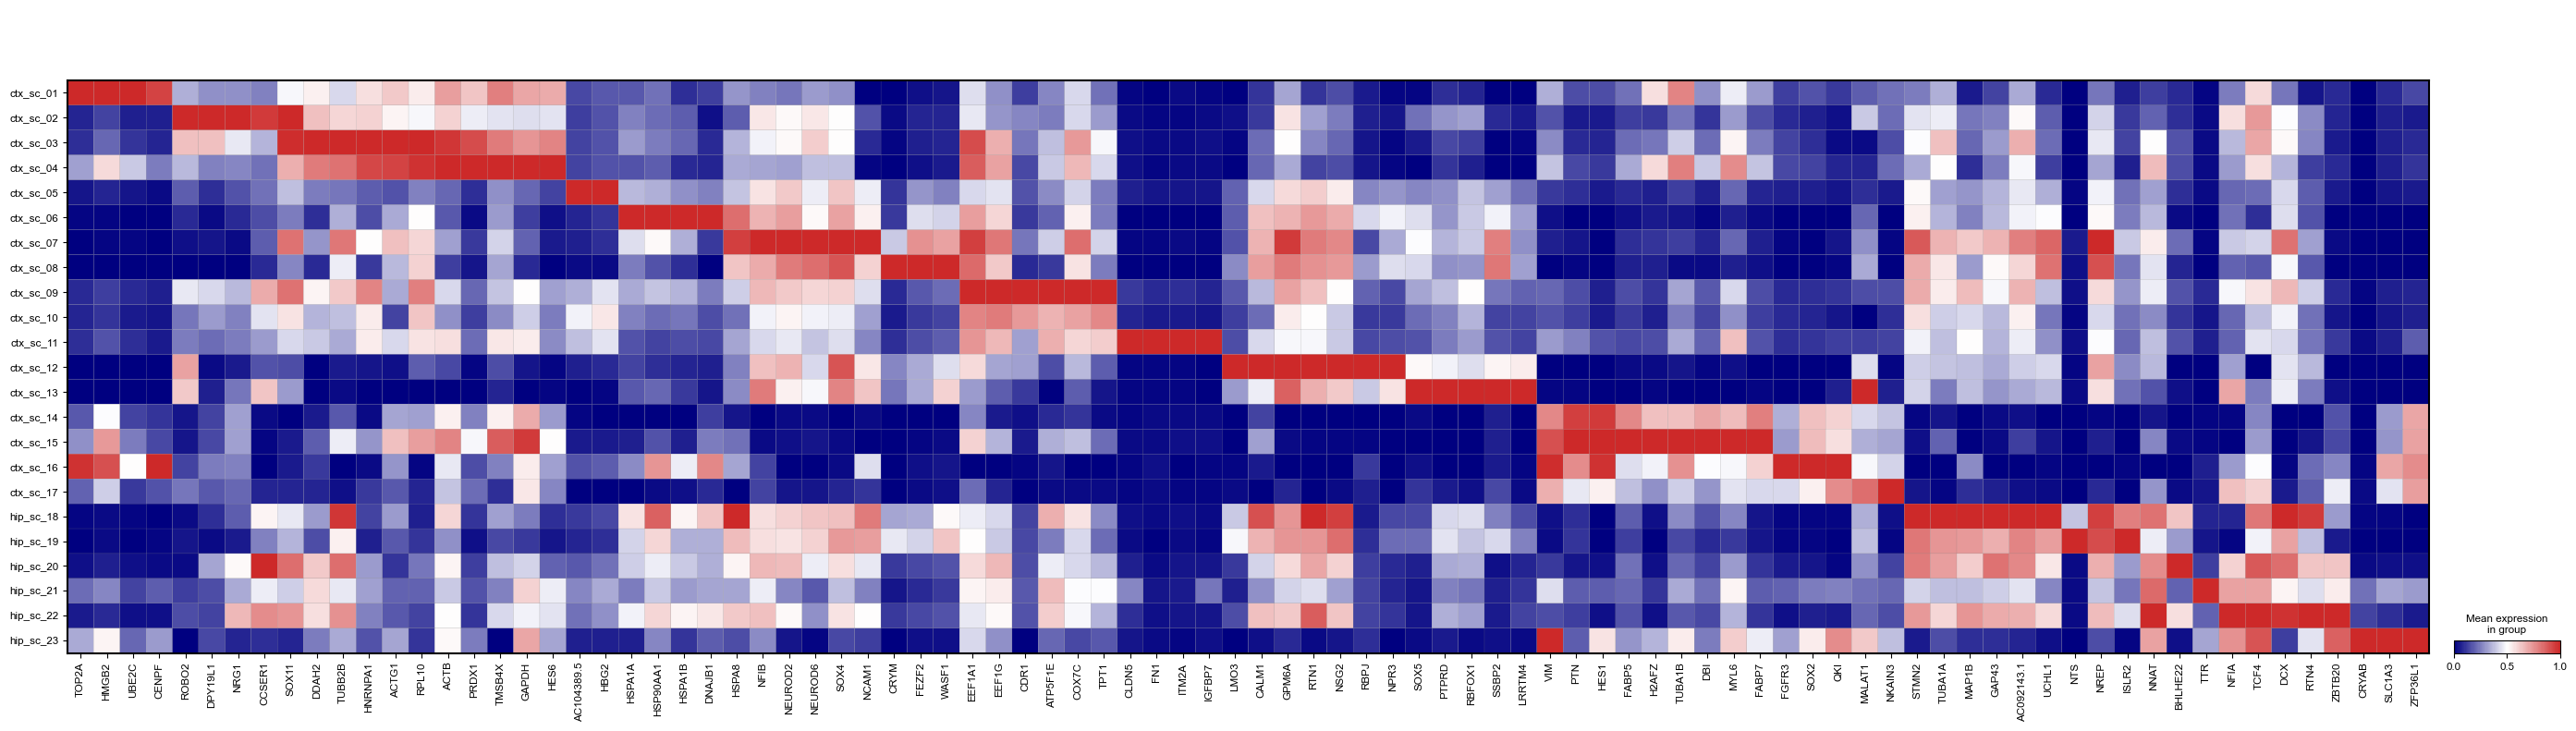

In [12]:
sc.pl.matrixplot(adata, 
                 var, 
                 'dmt_leiden_anno', 
                 standard_scale = 'var',
                 # dendrogram = True,
                 cmap = cmap,
                 show = False
                )
plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_single/matrixplot.pdf', bbox_inches = 'tight', dpi = 600)
# plt.close()

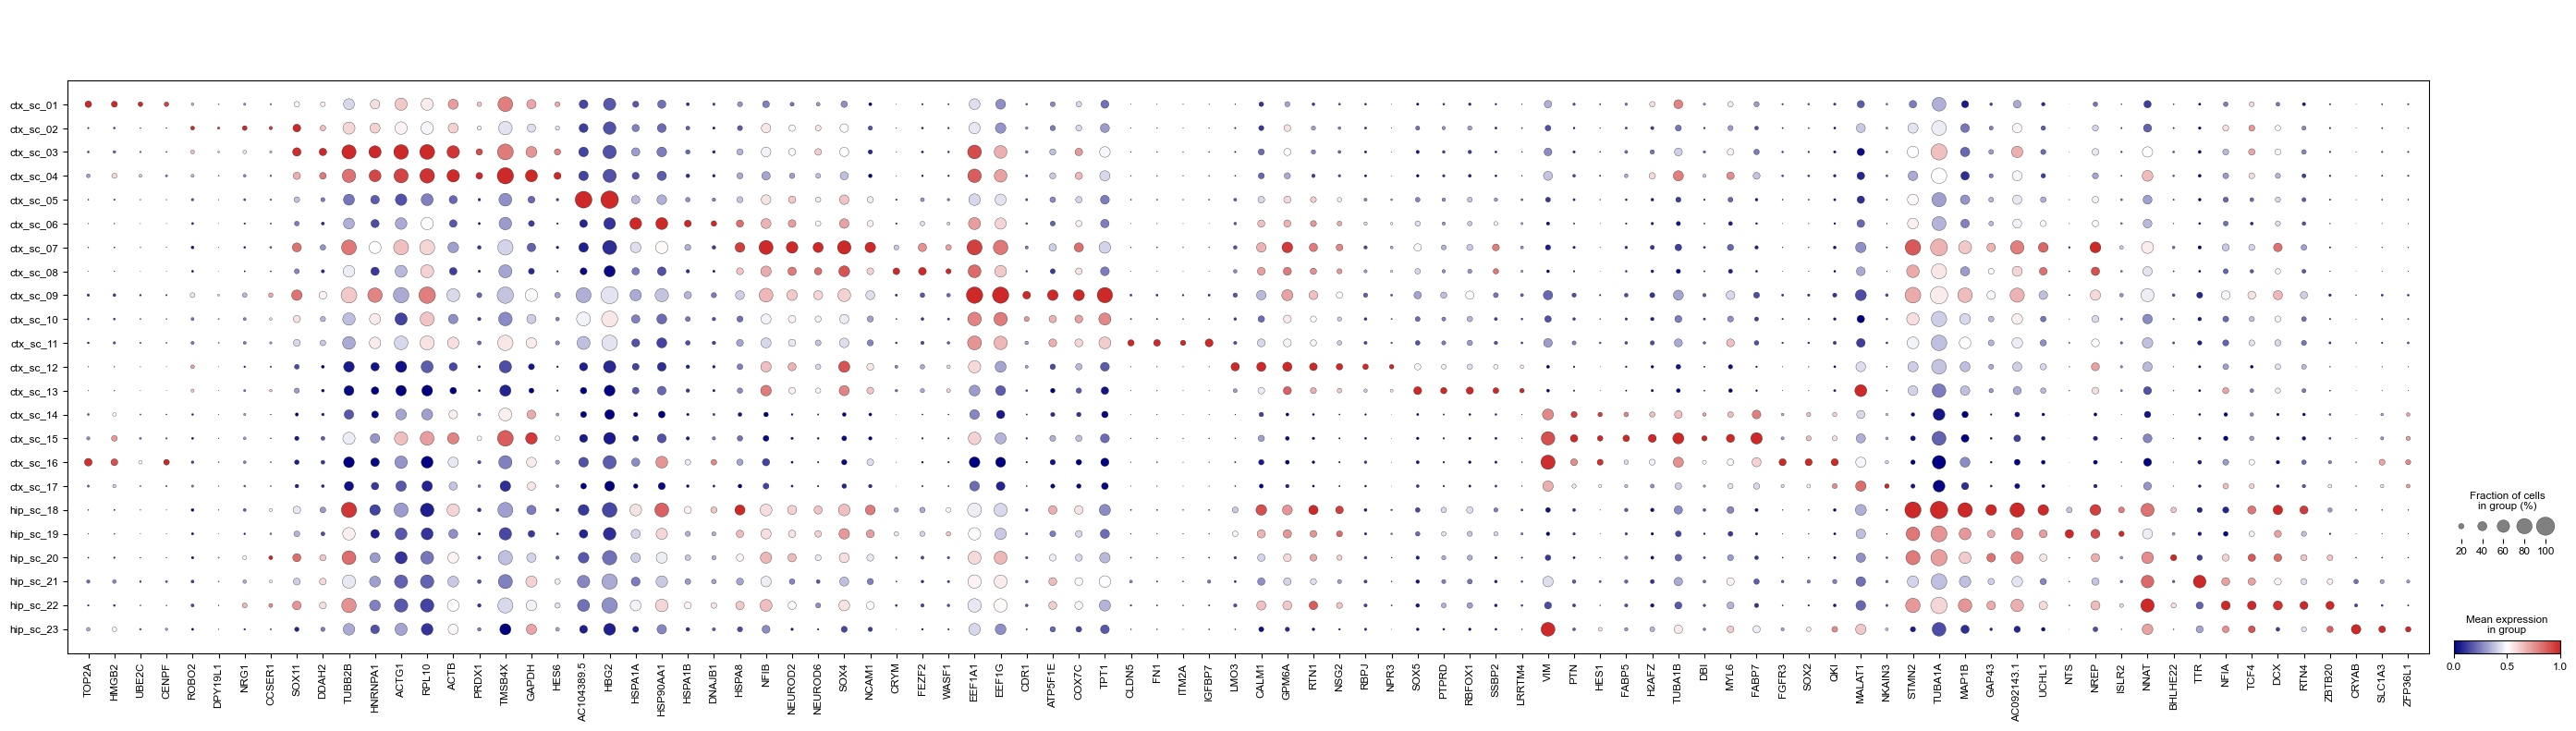

In [13]:
sc.pl.dotplot(adata, 
                 var, 
                 'dmt_leiden_anno', 
                 standard_scale = 'var',
              cmap = cmap,
              show = False
                )
plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_single/dotplot.pdf', bbox_inches = 'tight', dpi = 600)
# plt.close()

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# 创建画布和网格布局
fig = plt.figure(figsize=(64, 6))
gs = GridSpec(1, 15, figure=fig)

# 计算全局坐标范围
x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    
    x_min = min(x_min, adata_temp.obsm['align_spatial_2d'][:, 0].min())
    x_max = max(x_max, adata_temp.obsm['align_spatial_2d'][:, 0].max())
    y_min = min(y_min, adata_temp.obsm['align_spatial_2d'][:, 1].min())
    y_max = max(y_max, adata_temp.obsm['align_spatial_2d'][:, 1].max())

# 绘制子图
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    col = count % 15
    ax = fig.add_subplot(gs[0, col])
    
    # 绘制嵌入图
    sc.pl.embedding(
        adata_temp, basis="align_spatial_2d", color='dmt_leiden_anno',
        show=False, s=1, title='', legend_loc=None, ax=ax, palette=colormap
    )
    
    # 设置统一的坐标轴范围
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # 关闭坐标轴并设置等比例缩放
    ax.axis('off')
    ax.set_aspect('equal')
    # scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
    # ax.add_artist(scalebar)
    if count == 0:
        scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
        ax.add_artist(scalebar)
    count += 1
plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_single/spatial_plot_all.png', bbox_inches = 'tight', dpi = 600)
plt.close()
# plt.show()

In [15]:
for i in set(adata.obs['dmt_leiden_anno']):
    fig = plt.figure(figsize=(64, 6))
    # 计算全局坐标范围
    x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')
    for name in names:
        adata_temp = adata[adata.obs['slice_code'] == name].copy()
        adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
        adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

        x_min = min(x_min, adata_temp.obsm['align_spatial_2d'][:, 0].min())
        x_max = max(x_max, adata_temp.obsm['align_spatial_2d'][:, 0].max())
        y_min = min(y_min, adata_temp.obsm['align_spatial_2d'][:, 1].min())
        y_max = max(y_max, adata_temp.obsm['align_spatial_2d'][:, 1].max())
    
    gs = GridSpec(1, 15, figure=fig)
    count = 0
    for name in names:
        adata_temp = adata[adata.obs['slice_code'] == name].copy()
        adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
        adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

        row = (count // 15) + 1
        col = count % 15  
        ax = fig.add_subplot(gs[0, col])
        sc.pl.embedding(
            adata_temp, basis="align_spatial_2d", color='dmt_leiden_anno',
            show=False, s=1, title='', legend_loc=None, ax=ax, palette=colormap, groups = i,
        )
        
        # 设置统一的坐标轴范围
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        ax.axis('off')
        ax.set_aspect('equal')
        
        if count == 0:
            scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
            ax.add_artist(scalebar)
        count+=1

    plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_single/spatial_plot_{i}.png', bbox_inches = 'tight', dpi = 600)
    plt.close()

In [14]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/0106/Hippocampus_latent_embeddings_all_spatial_pretrain/dmt_leiden_20250108_1.h5ad')
adata

AnnData object with n_obs × n_vars = 1112773 × 33326
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [15]:
dic = {
    '0': 'Hip0_COLA4A1_vessel',
    '1': 'Hip1_ZBTB20_PCDH20_allo1',
    '2': 'Hip2_PPP1R17_ELMO3_SVZ',
    '3': 'Hip3_NTS_allo2',
    '4': 'Hip4_AC144831.1',
    '5': 'Hip5_POU3F1_IZ',
    '6': 'Hip2_PPP1R17_ELMO3_SVZ',
    '7': 'Hip7_WNT7B_GPR22_CP&SP',
    '8': 'Hip4_AC144831.1',
    '9': 'Hip7_WNT7B_GPR22_CP&SP',
    '10': 'Hip5_POU3F1_IZ',
    '11': 'Hip8_HOPX_FABP7_VZ',
    '12': 'Hip8_HOPX_FABP7_VZ',
    '13': 'Hip5_POU3F1_IZ',
    '14': 'Hip8_HOPX_FABP7_VZ',
    '15': 'Hip6_COL4A1_vessel',
    '16': 'Hip5_POU3F1_IZ',
    '17': 'Hip1_ZBTB20_PCDH20_allo1',
    '18': 'Hip8_HOPX_FABP7_VZ',
    '19': 'Hip7_WNT7B_GPR22_CP&SP',
    '20': 'Hip8_HOPX_FABP7_VZ',
    '21': 'Hip4_AC144831.1',
    '22': 'Hip1_ZBTB20_PCDH20_allo1',
    '23': 'Hip8_HOPX_FABP7_VZ',
    '24': 'Hip2_PPP1R17_ELMO3_SVZ',
    '25': 'Hip4_AC144831.1',
    '26': 'Hip9_PPP1R17_EOMES_SVZ',
    '27': 'Hip4_AC144831.1',
    '28': 'Hip1_ZBTB20_PCDH20_allo1',
    '29': 'Hip7_WNT7B_GPR22_CP&SP',
    '30': 'Hip8_HOPX_FABP7_VZ',
    '31': 'Hip8_HOPX_FABP7_VZ',
    '32': 'Hip1_ZBTB20_PCDH20_allo1',
    '33': 'Hip3_NTS_allo2',
    '34': 'Hip10_COL4A1_vessel',
    '35': 'NA',
    '36': 'NA',
    '37': 'Hip1_ZBTB20_PCDH20_allo1',
    '38': 'Hip7_WNT7B_GPR22_CP&SP',
    '39': 'Hip7_WNT7B_GPR22_CP&SP',
    '40': 'Hip7_WNT7B_GPR22_CP&SP',
}

adata.obs['dmt_leiden_merge'] = [dic[i] for i in adata.obs['dmt_leiden']]
colormap = {
    'Hip0_COLA4A1_vessel': '#cdec1d',
    'Hip1_ZBTB20_PCDH20_allo1': '#e87bb8',
     'Hip2_PPP1R17_ELMO3_SVZ': '#d33d03',
 'Hip3_NTS_allo2': '#efe245',
 'Hip4_AC144831.1': '#e1e0b7',
 'Hip5_POU3F1_IZ': '#ff9186',
 'Hip6_COL4A1_vessel': '#553b12',
 'Hip7_WNT7B_GPR22_CP&SP': '#507d87',
 'Hip8_HOPX_FABP7_VZ': '#466e1e',
 'Hip9_PPP1R17_EOMES_SVZ': '#931757',
    'Hip10_COL4A1_vessel': '#E65100'
}

adata = adata[adata.obs['dmt_leiden_merge'] != 'NA'].copy()

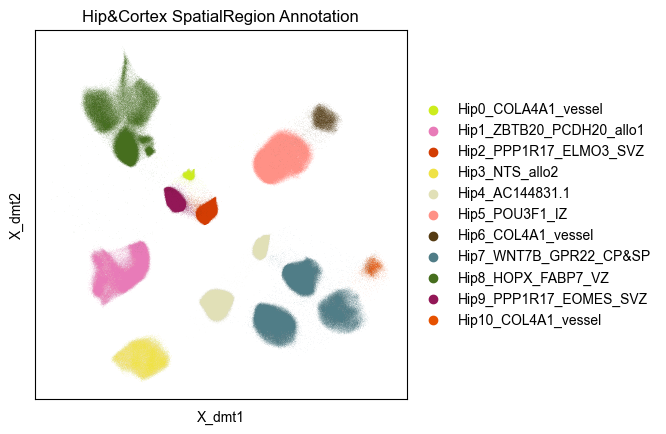

In [16]:
plot = sc.pl.embedding(adata, basis = 'X_dmt',color = 'dmt_leiden_merge', palette = colormap, show = False, title = 'Hip&Cortex SpatialRegion Annotation'); 
plot.set_aspect('equal')
plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_spatial/dmt_plot.png', bbox_inches = 'tight', dpi = 600)

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# 创建画布和网格布局
fig = plt.figure(figsize=(64, 6))
gs = GridSpec(1, 15, figure=fig)

# 计算全局坐标范围
x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    
    x_min = min(x_min, adata_temp.obsm['align_spatial_2d'][:, 0].min())
    x_max = max(x_max, adata_temp.obsm['align_spatial_2d'][:, 0].max())
    y_min = min(y_min, adata_temp.obsm['align_spatial_2d'][:, 1].min())
    y_max = max(y_max, adata_temp.obsm['align_spatial_2d'][:, 1].max())

# 绘制子图
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    col = count % 15
    ax = fig.add_subplot(gs[0, col])
    
    sc.pl.embedding(
        adata_temp, basis="align_spatial_2d", color='dmt_leiden_merge',
        show=False, s=1, title='', legend_loc=None, ax=ax, palette=colormap
    )
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    ax.axis('off')
    ax.set_aspect('equal')
    if count == 0:
        scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
        ax.add_artist(scalebar)
    count += 1

plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_spatial/spatial_plot_all.png', bbox_inches = 'tight', dpi = 600)
plt.close()

In [23]:
for i in set(adata.obs['dmt_leiden_merge']):
    fig = plt.figure(figsize=(64, 6))
    # 计算全局坐标范围
    x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')
    for name in names:
        adata_temp = adata[adata.obs['slice_code'] == name].copy()
        adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
        adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

        x_min = min(x_min, adata_temp.obsm['align_spatial_2d'][:, 0].min())
        x_max = max(x_max, adata_temp.obsm['align_spatial_2d'][:, 0].max())
        y_min = min(y_min, adata_temp.obsm['align_spatial_2d'][:, 1].min())
        y_max = max(y_max, adata_temp.obsm['align_spatial_2d'][:, 1].max())
    
    gs = GridSpec(1, 15, figure=fig)
    count = 0
    for name in names:
        adata_temp = adata[adata.obs['slice_code'] == name].copy()
        adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
        adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

        row = (count // 15) + 1
        col = count % 15  
        ax = fig.add_subplot(gs[0, col])
        sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='dmt_leiden_merge', 
                        show=False, s=1, title='', legend_loc=None, ax=ax, palette = colormap, groups = i)
        
        # 设置统一的坐标轴范围
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        ax.axis('off')
        ax.set_aspect('equal')
        
        if count == 0:
            scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
            ax.add_artist(scalebar)
        count += 1

    plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_spatial/spatial_plot_{i}.png', bbox_inches = 'tight', dpi = 600)
    plt.close()

In [17]:
adatas = []
for i in set(adata.obs['slice_code']):
    temp = adata[adata.obs['slice_code'] == i].copy()
    sc.pp.normalize_total(temp)
    sc.pp.log1p(temp)
    sc.pp.scale(temp, zero_center=False, max_value=10)
    adatas.append(temp)
adata = ad.concat(adatas)

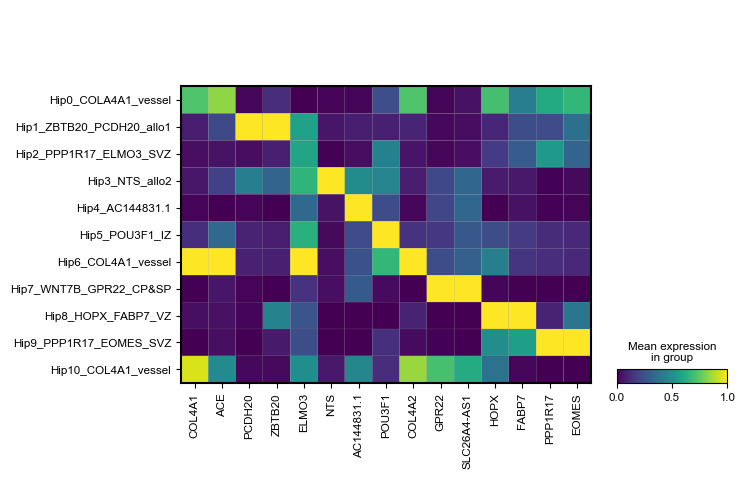

In [18]:
var = [
    'COL4A1','ACE',
    
    'PCDH20','ZBTB20',
    
    'ELMO3',
    
    'NTS',
    'AC144831.1',
    
    'POU3F1',
    'COL4A2',
    'GPR22','SLC26A4-AS1',
    
    
    'HOPX','FABP7',
    
    'PPP1R17','EOMES',
]

sc.pl.matrixplot(adata, 
                 var, 
                 'dmt_leiden_merge', 
                 standard_scale = 'var',
                 # dendrogram = True,
                 show = False
                )
plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_spatial/matrixplot.pdf', bbox_inches = 'tight', dpi = 600)
# plt.close()
# plt.show()

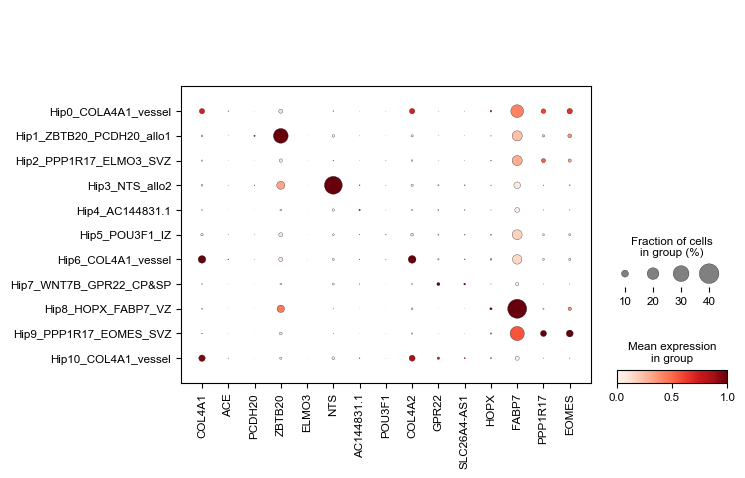

In [19]:
sc.pl.dotplot(adata, 
                 var, 
                 'dmt_leiden_merge', 
                 standard_scale = 'var',
                 # dendrogram = True,
                 show = False
                )



plt.savefig(f'/data/work/05.cluster/FuseMap/0116/hip_spatial/dotplot.pdf', bbox_inches = 'tight', dpi = 600)
# plt.close()


In [27]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

colors = ["#D1CFD2", "#CAC4CF", '#B3A1C5', '#695DAC', "#707FBD"]
cmap = LinearSegmentedColormap.from_list("GrayToPurple", colors, N=256)

In [28]:
for i in ['NNAT','NTS','ZBTB20','BCL11A','BCL11B','SATB1','SATB2']:
    fig = plt.figure(figsize=(64, 6))
    # 计算全局坐标范围
    x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')
    for name in names:
        adata_temp = adata[adata.obs['slice_code'] == name].copy()
        adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
        adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

        x_min = min(x_min, adata_temp.obsm['align_spatial_2d'][:, 0].min())
        x_max = max(x_max, adata_temp.obsm['align_spatial_2d'][:, 0].max())
        y_min = min(y_min, adata_temp.obsm['align_spatial_2d'][:, 1].min())
        y_max = max(y_max, adata_temp.obsm['align_spatial_2d'][:, 1].max())
    
    gs = GridSpec(1, 15, figure=fig)
    count = 0
    for name in names:
        adata_temp = adata[adata.obs['slice_code'] == name].copy()
        adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
        adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

        row = (count // 15) + 1
        col = count % 15  
        ax = fig.add_subplot(gs[0, col])
        sc.pl.embedding(adata_temp, basis="align_spatial_2d", color=i, 
                        show=False, s=1, title='', legend_loc='upper right', ax=ax, cmap = cmap)

                
        # 设置统一的坐标轴范围
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        ax.axis('off')
        ax.set_aspect('equal')
        
        if count == 0:
            scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
            ax.add_artist(scalebar)
        count += 1

    plt.savefig(f'/data/work/05.cluster/FuseMap/0116/marker_plot/{i}.png', bbox_inches = 'tight', dpi = 600)
    plt.close()
    break